# **PCA and t-SNE Project: Auto MPG**


Welcome to the project on PCA and t-SNE. In this project, we will be using the **auto-mpg dataset**.


-----------------------------
## **Context**
-----------------------------

The shifting market conditions, globalization, cost pressure, and volatility are leading to a change in the automobile market landscape. The emergence of data, in conjunction with machine learning in automobile companies, has paved a way that is helping bring operational and business transformations.

The automobile market is vast and diverse, with numerous vehicle categories being manufactured and sold with varying configurations of attributes such as displacement, horsepower, and acceleration. We aim to find combinations of these features that can clearly distinguish certain groups of automobiles from others through this analysis, as this will inform other downstream processes for any organization aiming to sell each group of vehicles to a slightly different target audience.

You are a Data Scientist at SecondLife which is a leading used car dealership with numerous outlets across the US. Recently, they have started shifting their focus to vintage cars and have been diligently collecting data about all the vintage cars they have sold over the years. The Director of Operations at SecondLife wants to leverage the data to extract insights about the cars and find different groups of vintage cars to target the audience more efficiently.

-----------------------------
## **Objective**
-----------------------------
The objective of this problem is to **explore the data, reduce the number of features by using dimensionality reduction techniques like PCA and t-SNE, and extract meaningful insights**.

-----------------------------
## **Dataset**
-----------------------------
There are 8 variables in the data:

- mpg: miles per gallon
- cyl: number of cylinders
- disp: engine displacement (cu. inches) or engine size
- hp: horsepower
- wt: vehicle weight (lbs.)
- acc: time taken to accelerate from 0 to 60 mph (sec.)
- yr: model year
- car name: car model name

## **Importing the necessary libraries and overview of the dataset**

In [ ]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

# To scale the data using z-score
from sklearn.preprocessing import StandardScaler

# Importing PCA and t-SNE
from sklearn.decomposition import PCA

from sklearn.manifold import TSNE

### **Loading the data**

In [ ]:
mpg_file=pd.read_csv("auto_mpg.csv")

In [ ]:
mpg_file.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name
0,18.0,8,307.0,130,3504,12.0,70,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,ford torino
5,15.0,8,429.0,198,4341,10.0,70,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,amc ambassador dpl


In [ ]:
print(mpg_file.shape)
print(mpg_file.columns)

(398, 8)
Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'car name'],
      dtype='object')


In [ ]:
mpg_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   car name      398 non-null    object 
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


In [ ]:
mpg_file.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
car name,0


No missing values, except the horse power column is in string format instead of int format. change to numeric

### **Data Overview**

- Observations
- Sanity checks




In [ ]:
# chnage horsepower column to numeric
mpg_file["horsepower"] = pd.to_numeric(mpg_file["horsepower"], errors="coerce")
print(mpg_file.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model year        int64
car name         object
dtype: object


In [ ]:
print(mpg_file.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
car name        0
dtype: int64


# after converting to numeric i see 6 missing values in horsepower column. Fill this missing values with median values

In [ ]:
# fill those 6 missing values with median
mpg_file["horsepower"] = mpg_file["horsepower"].fillna(mpg_file["horsepower"].median())
print(mpg_file.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
car name        0
dtype: int64


Now the data is clean

## **Data Preprocessing and Exploratory Data Analysis**


- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- Missing value treatment
- Feature engineering (if needed)
- Check the correlation among the variables
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)



In [ ]:
# changed the columns names with spaces replaced with (_) for the columns model year and car name
mpg_file.columns = mpg_file.columns.str.strip().str.lower().str.replace(" ", "_")
print(mpg_file.columns)

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'car_name'],
      dtype='object')


### **Summary Statistics**

In [ ]:
mpg_file.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
horsepower,398.0,104.304020,38.222625,46.0,76.000,93.5,125.000,230.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model_year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0


**Observations:________**The summary statistics show that the dataset contains 398 cars and has a good amount of variation across the features. The average mpg is about 23.5, with values ranging from 9.0 to 46.6, showing that the dataset includes both low and high fuel-efficient cars. Horsepower also varies widely, from 46 to 230, and weight ranges from 1613 to 5140, which suggests a mix of small lighter cars and large heavier cars. Overall, the wide spread in variables like mpg, displacement, horsepower, and weight shows that the dataset is diverse enough for PCA and t-SNE analysis

mpg
Skew : 0.46


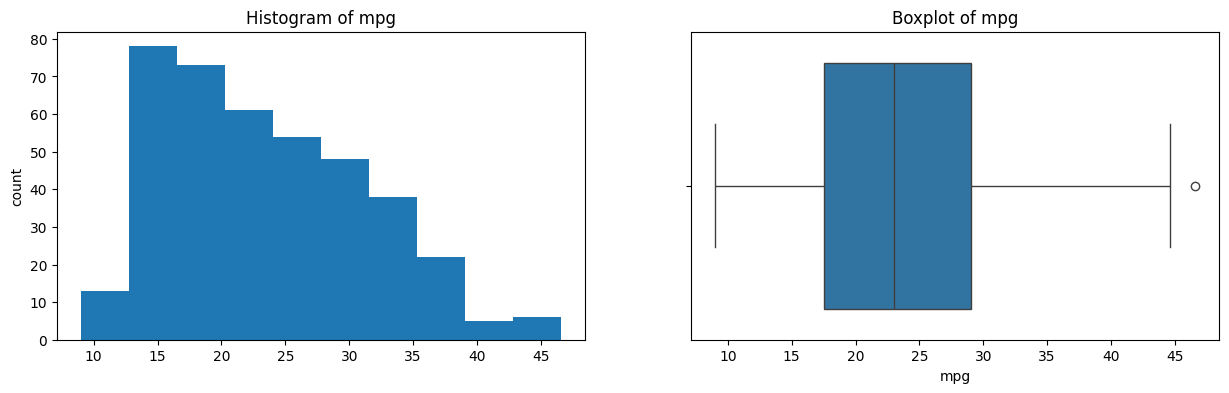

cylinders
Skew : 0.53


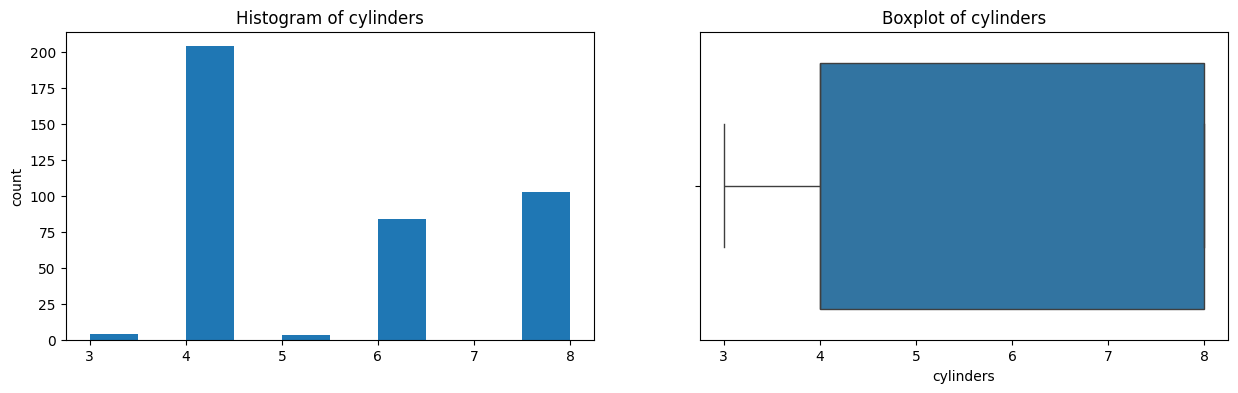

displacement
Skew : 0.72


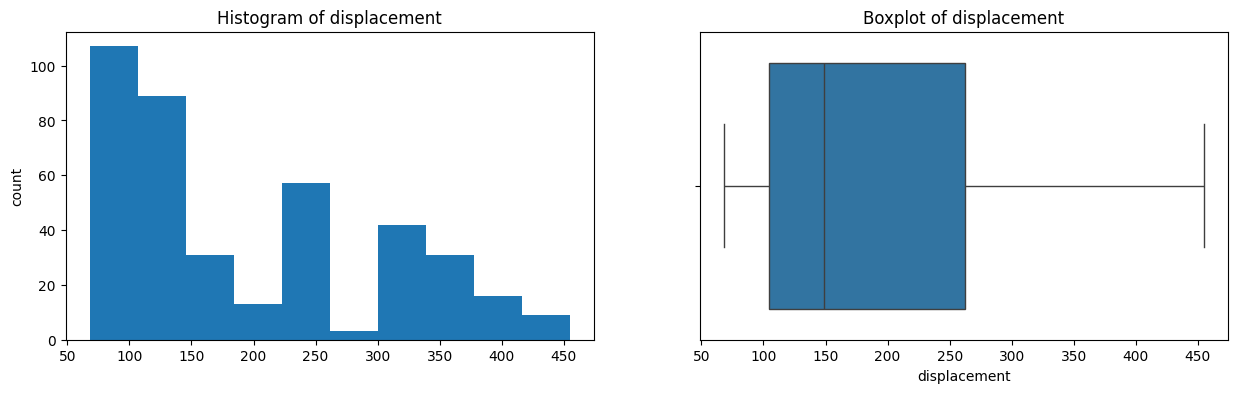

horsepower
Skew : 1.11


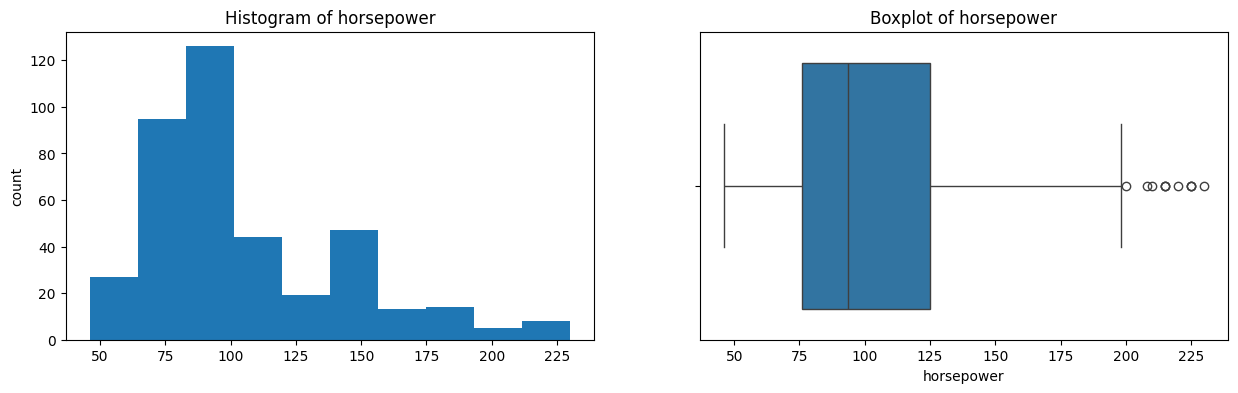

weight
Skew : 0.53


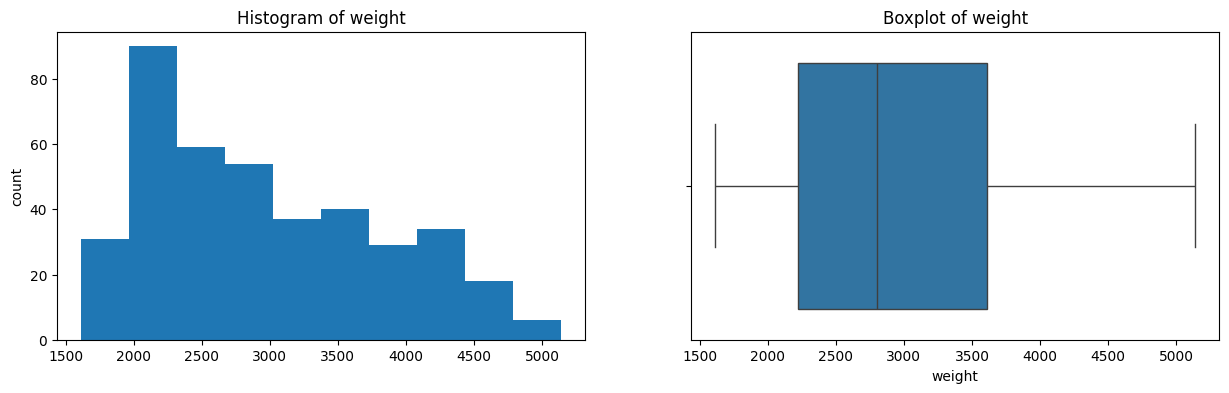

acceleration
Skew : 0.28


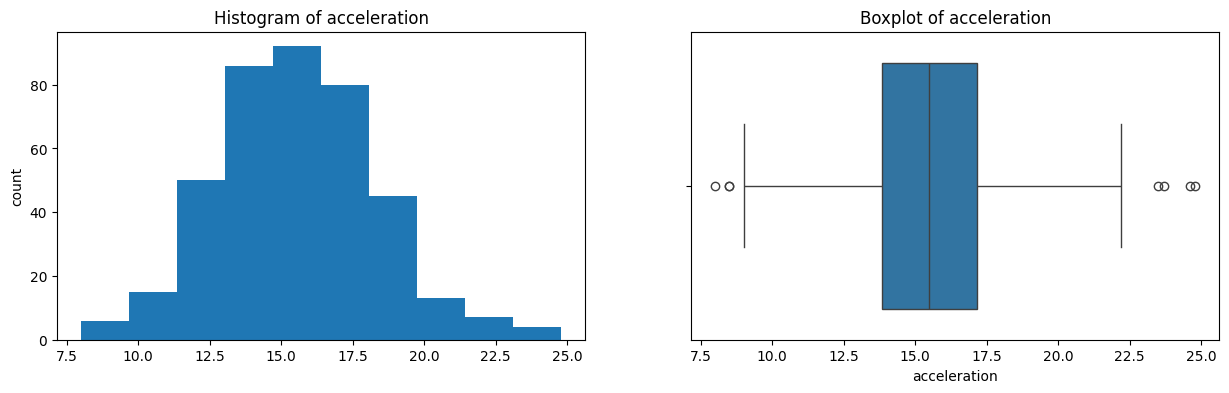

model_year
Skew : 0.01


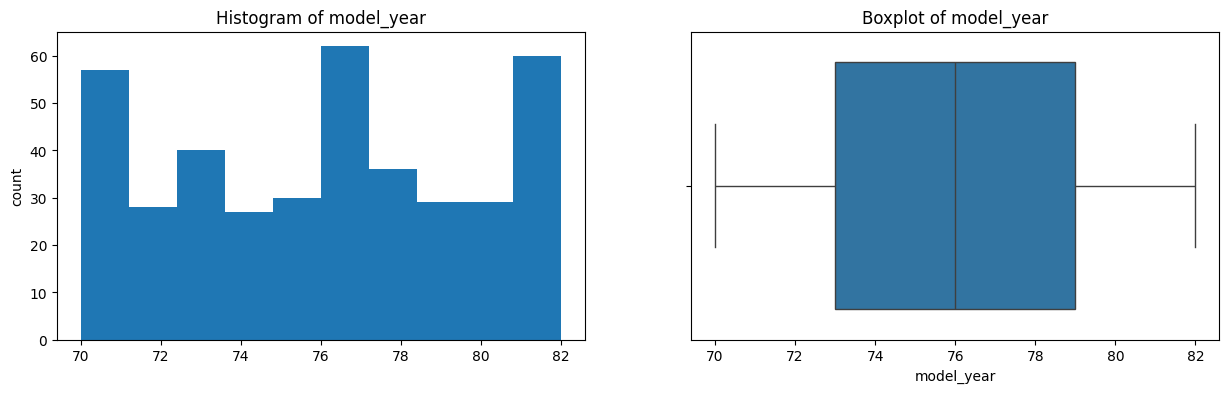

In [ ]:
result = mpg_file.select_dtypes(include='number')

cont_cols = list(result.columns)

for col in cont_cols:
    print(col)
    print('Skew :', round(mpg_file[col].skew(), 2))

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 2, 1)
    mpg_file[col].hist(bins=10, grid=False)
    plt.ylabel('count')
    plt.title(f'Histogram of {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=mpg_file[col])
    plt.title(f'Boxplot of {col}')

    plt.show()

Most variables show mild positive skewness. Horsepower (1.11) and displacement (0.72) are more right-skewed than the others, which matches the higher values seen in the boxplots. Modelyear is almost symmetric with skewness close to 0. Since the skewness is not too severe, no transformation was applied.

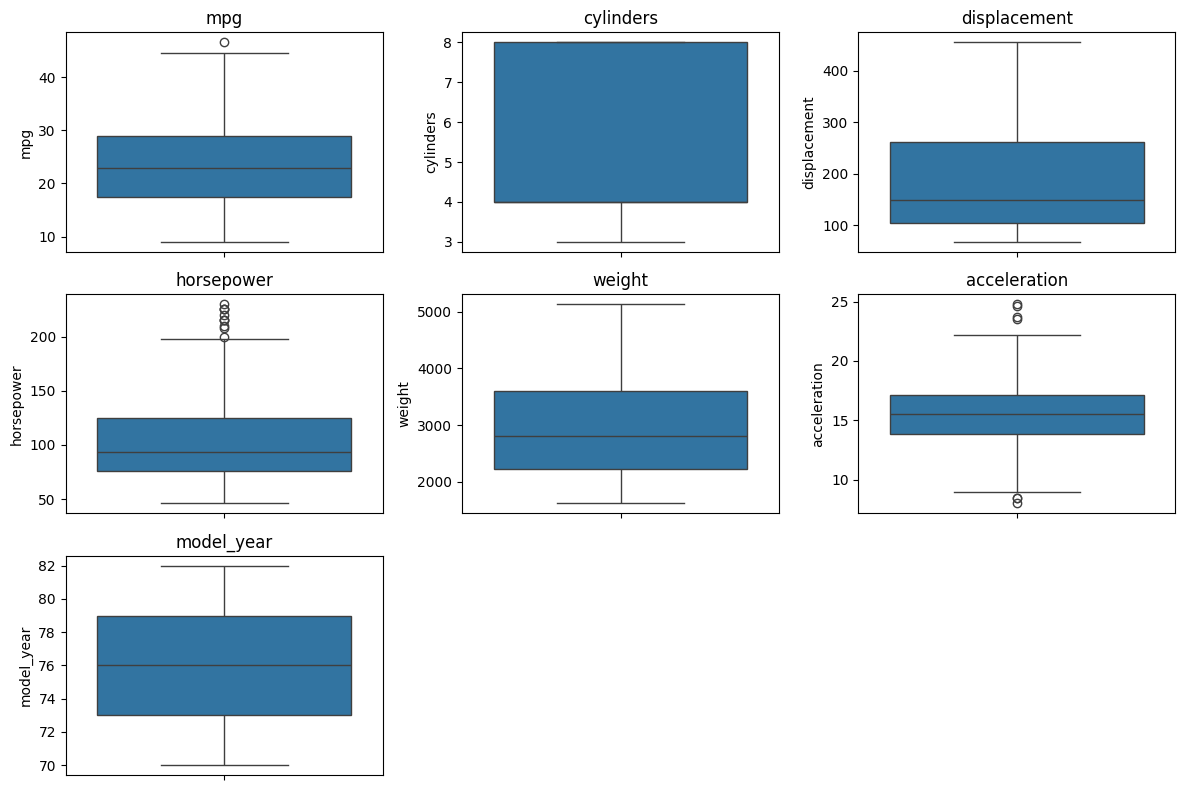

In [ ]:
features = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

plt.figure(figsize=(12,8))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=mpg_file[col])
    plt.title(col)
plt.tight_layout()
plt.show()

The boxplots show some extreme values, mainly in horsepower, acceleration, and mpg. These were kept because they likely represent actual variation in the cars rather than incorrect data. No outlier treatment was applied before PCA and t-SNE

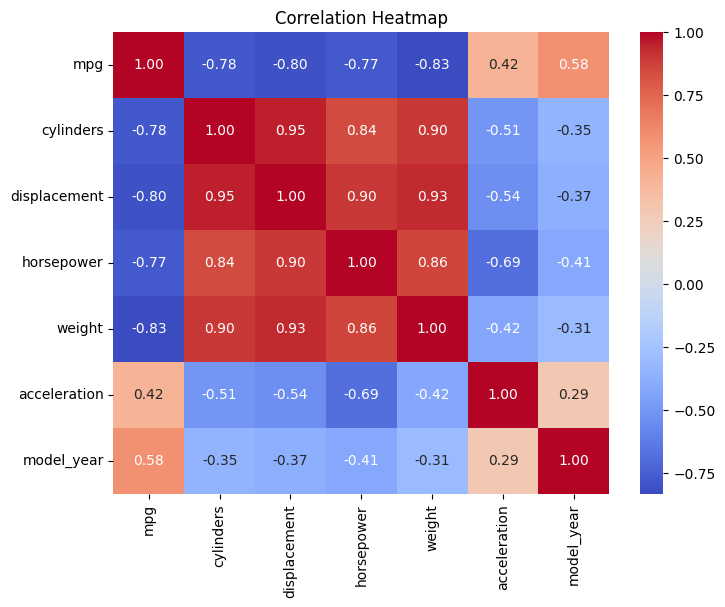

In [ ]:
# check correlation among variables. did not include car_name columns as it is the text column not important for PCA and tsne.
features = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

plt.figure(figsize=(8,6))
sns.heatmap(mpg_file[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows some strong relationships between the car features. MPG is strongly negatively correlated with weight (-0.83), displacement (-0.80), cylinders (-0.78), and horsepower (-0.77), which means bigger, heavier, and more powerful cars usually have lower fuel efficiency. Cylinders, displacement, horsepower, and weight are also strongly positively correlated with each other, showing that these features are related to vehicle size and engine power. Model year has a positive correlation with mpg (0.58), suggesting that newer cars in the dataset tend to be more fuel efficient. Since many variables are closely related, PCA can help reduce the number of features while still keeping the main information in the data.

### **Scaling the data**

In [ ]:
# scaling data because variables are measured on different ranges
X = mpg_file[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Before applying PCA and t-SNE, the numeric features were scaled using StandardScaler. This step was necessary because the variables are measured on different ranges. Scaling ensures that no single variable, such as weight or displacement, dominates the analysis only because of its larger magnitude.

In [ ]:
print(X_scaled[:5])

[[-0.7064387   1.49819126  1.0906037   0.67311762  0.63086987 -1.29549834
  -1.62742629]
 [-1.09075062  1.49819126  1.5035143   1.58995818  0.85433297 -1.47703779
  -1.62742629]
 [-0.7064387   1.49819126  1.19623199  1.19702651  0.55047045 -1.65857724
  -1.62742629]
 [-0.96264665  1.49819126  1.06179598  1.19702651  0.54692342 -1.29549834
  -1.62742629]
 [-0.83454267  1.49819126  1.04259084  0.93507207  0.56584093 -1.84011669
  -1.62742629]]


The scaled output confirms that standardization was applied successfully. After scaling, all features are on a comparable scale centered around zero. Negative values represent observations below the mean, while positive values represent observations above the mean. This step is important because PCA and tSNE are sensitive to differences.

## **Principal Component Analysis**

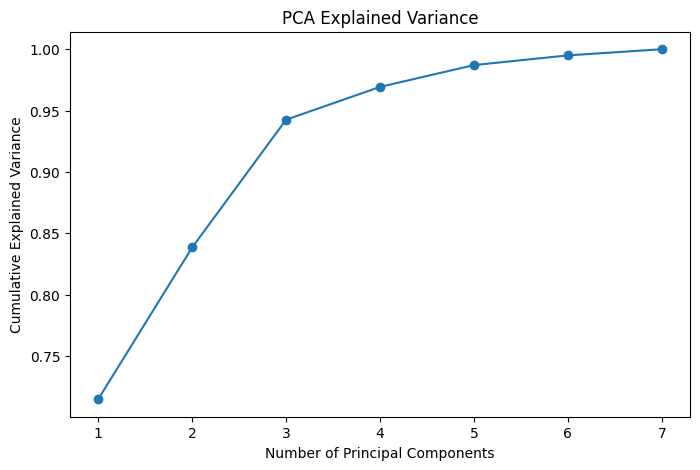

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

**Observations:___________________** Most of the information in the dataset is captured within the first few components. That means PCA is working well here, and the original 7 variables can be reduced to a smaller number of components without losing much information.

The first principal component explains about 72% of the variance.
The first 2 components together explain about 84%.
The first 3 components explain about 94% of the variance.

#### **Interpret the coefficients of the first three principal components from the below DataFrame**

In [ ]:
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca_3.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=features
)

print(loadings)

                   PC1       PC2       PC3
mpg          -0.397737  0.211430 -0.256579
cylinders     0.416485  0.191612  0.140786
displacement  0.429713  0.177428  0.103649
horsepower    0.422311  0.090327 -0.168064
weight        0.414224  0.221956  0.279668
acceleration -0.284828 -0.024110  0.892645
model_year   -0.229428  0.910548 -0.018109


**Observations:__________________** The first principal component mainly represents vehicle size and engine power, as it has high positive values for cylinders, displacement, horsepower, and weight, while mpg loads in the minus direction. The second principal component is mostly influenced by model year, so it captures the difference between older and newer cars. The third principal component is mainly driven by acceleration, which suggests it reflects performance related differences among cars.

#### **Visualize the data in 2 dimensions using the first two principal components**



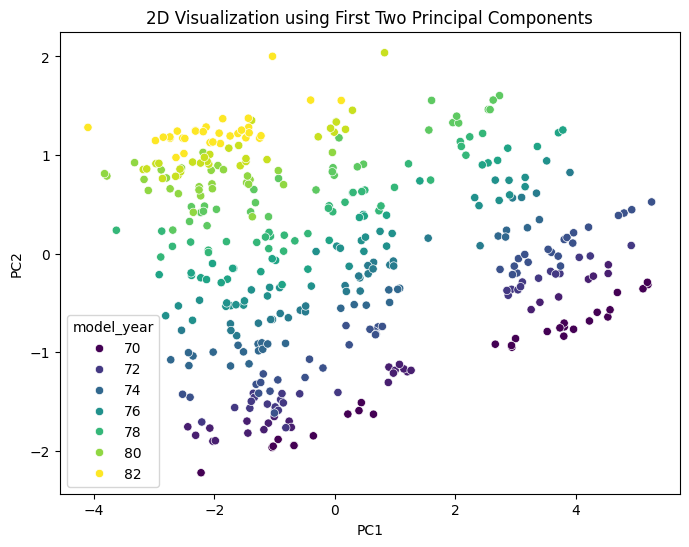

In [ ]:
pca_df["model_year"] = mpg_file["model_year"]

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="model_year", palette="viridis")
plt.title("2D Visualization using First Two Principal Components")
plt.show()

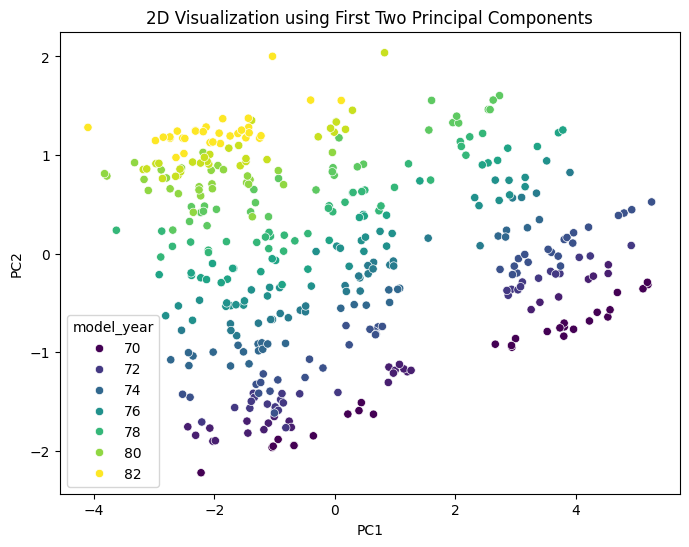

In [ ]:
pca_df["model_year"] = mpg_file["model_year"]

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="model_year", palette="viridis")
plt.title("2D Visualization using First Two Principal Components")
plt.show()

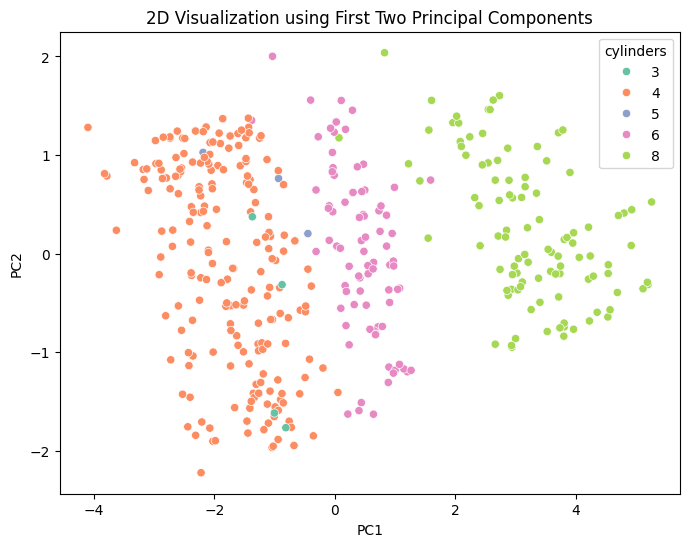

In [ ]:
# cylinders is used because of small number of categories like 3, 4, 5, 6,8. useful to see the clusters clearly
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
pca_df["cylinders"] = mpg_file["cylinders"]

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cylinders", palette="Set2")
plt.title("2D Visualization using First Two Principal Components")
plt.show()


**Observations:___________** The PCA plot shows visible grouping of cars based on the first two principal components. Most 8 cylinder cars are grouped on the right, 4 cylinder cars are mostly on the left, and 6 cylinder cars lie in between. This suggests that the first two components capture meaningful differences in vehicle size, power, and age. 3-cylinder and 5-cylinder cars are very few, so they appear as isolated points rather than clear groups.

## **t-SNE**

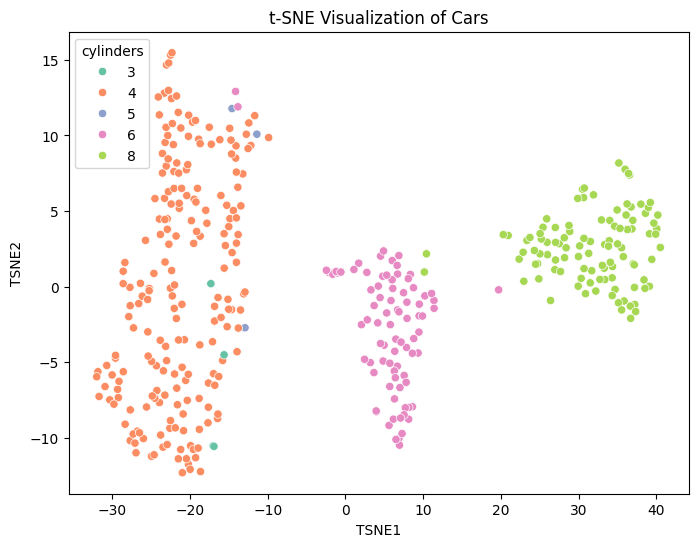

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])
tsne_df["cylinders"] = mpg_file["cylinders"]

plt.figure(figsize=(8,6))
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="cylinders", palette="Set2")
plt.title("t-SNE Visualization of Cars")
plt.show()

**Observations:______________** The t-SNE visualization shows more distinct grouping than the PCA plot. Most 4cylinder, 6cylinder, and 8cylinder cars form separate clusters, which suggests that the data has clear underlying patterns and natural groupings.

Compared with PCA, tSNE gives a more separated view of the groups. PCA captures the main variance in the data, while tSNE better highlights local similarity among the cars.

#### **Visualize the clusters w.r.t different variables using scatter plot and box plot**

In [ ]:
mpg_file["groups"] = tsne_df["groups"].values

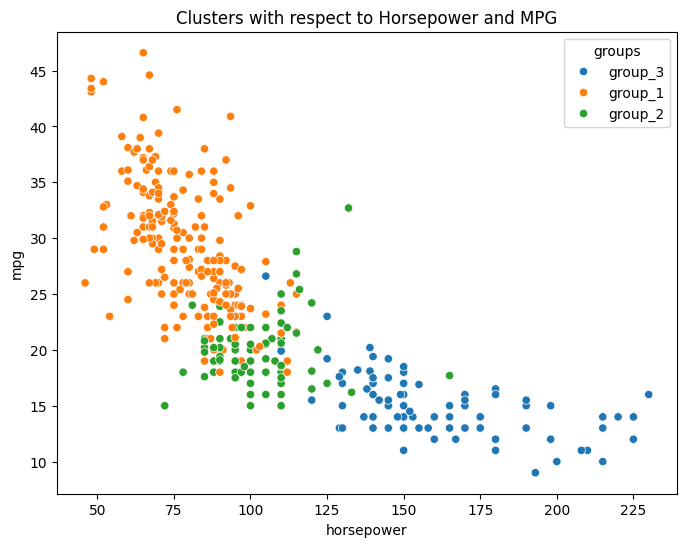

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=mpg_file, x="horsepower", y="mpg", hue="groups")
plt.title("Clusters with respect to Horsepower and MPG")
plt.show()

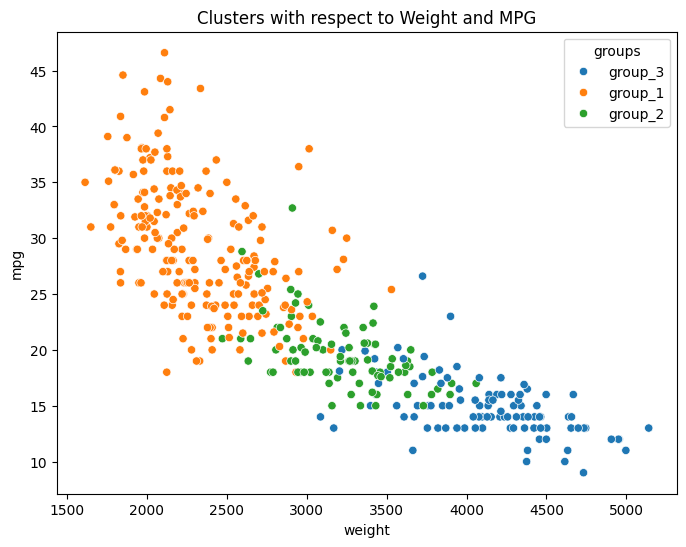

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=mpg_file, x="weight", y="mpg", hue="groups")
plt.title("Clusters with respect to Weight and MPG")
plt.show()

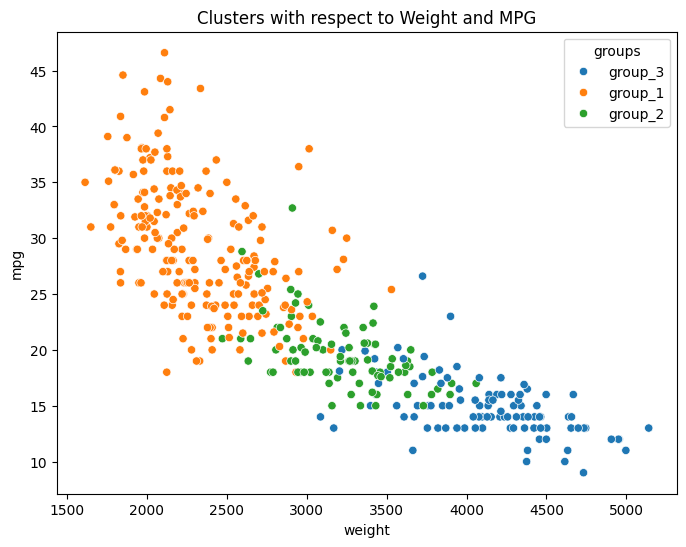

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=mpg_file, x="weight", y="mpg", hue="groups")
plt.title("Clusters with respect to Weight and MPG")
plt.show()

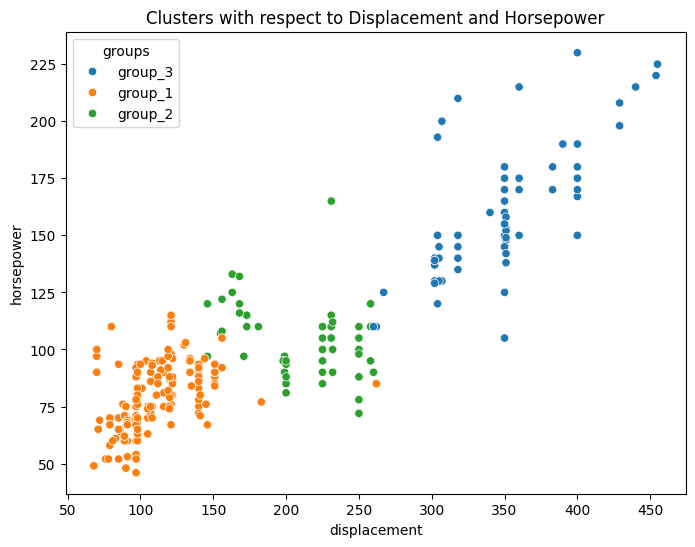

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=mpg_file, x="displacement", y="horsepower", hue="groups")
plt.title("Clusters with respect to Displacement and Horsepower")
plt.show()

**Observations**: The clusters are separated quite clearly across the original variables.
In the horsepower vs mpg plot, group_1 has lower horsepower and higher mpg, so these look like smaller and more fuel efficient cars.
group_3 has high horsepower and low mpg, which means these are bigger and more powerful cars with lower fuel efficiency.
group_2 falls in between, so it seems to represent medium range cars.
In the weight vs mpg plot, the same pattern is seen. Lighter cars are mostly in group_1, heavier cars are mostly in group_3, and group_2 is again in the middle.
In the displacement vs horsepower plot, group_1 is concentrated at lower displacement and horsepower, group_3 is concentrated at higher displacement and horsepower, and group_2 lies between the two.

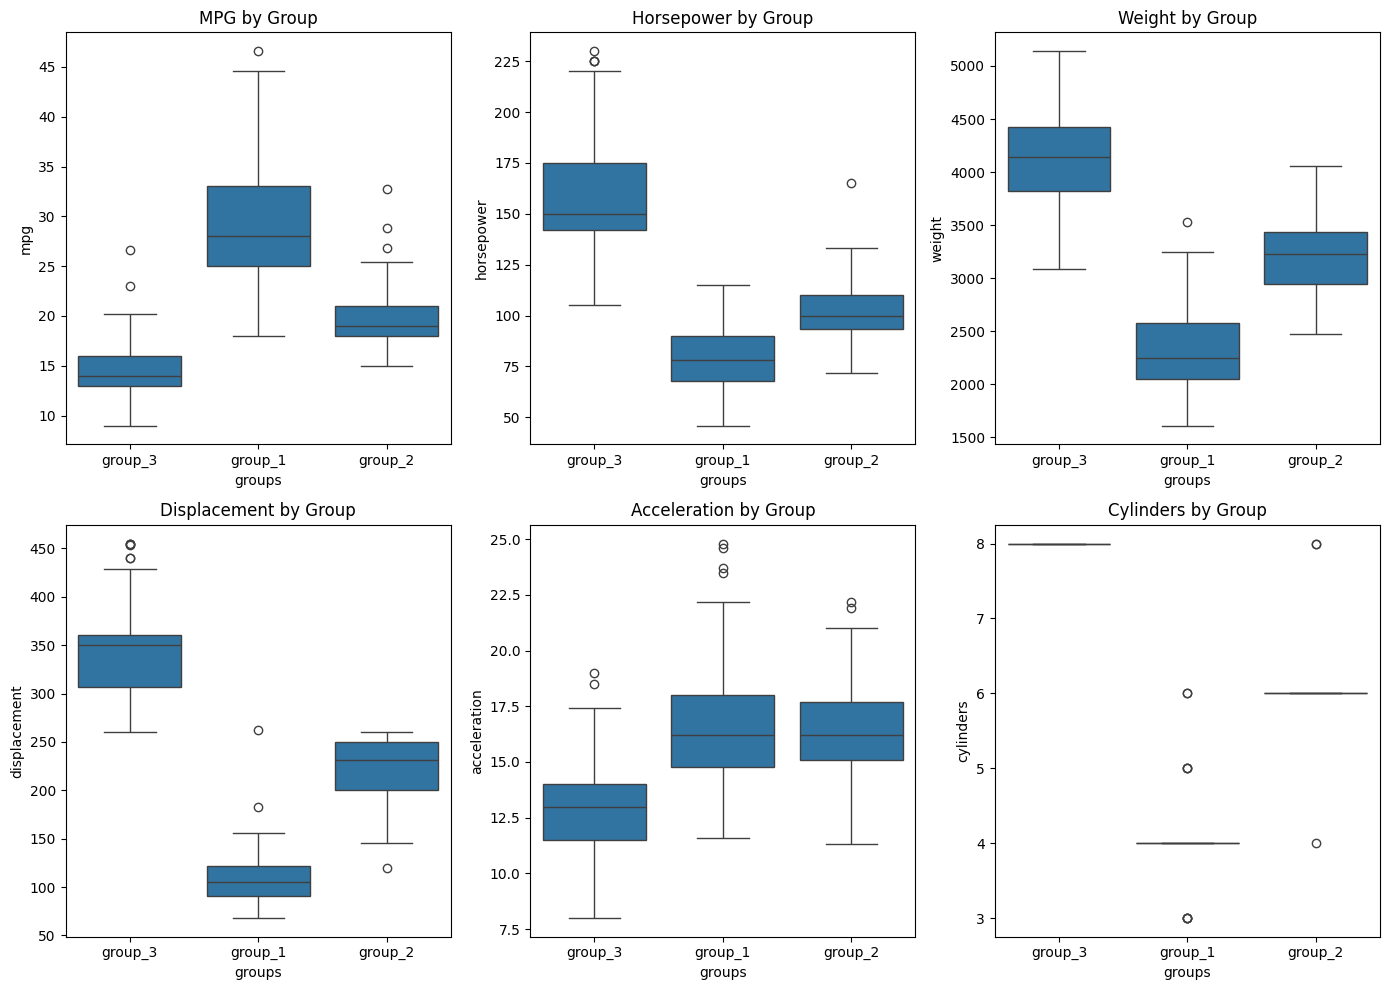

In [ ]:
plt.figure(figsize=(14,10))

plt.subplot(2,3,1)
sns.boxplot(data=mpg_file, x="groups", y="mpg")
plt.title("MPG by Group")

plt.subplot(2,3,2)
sns.boxplot(data=mpg_file, x="groups", y="horsepower")
plt.title("Horsepower by Group")

plt.subplot(2,3,3)
sns.boxplot(data=mpg_file, x="groups", y="weight")
plt.title("Weight by Group")

plt.subplot(2,3,4)
sns.boxplot(data=mpg_file, x="groups", y="displacement")
plt.title("Displacement by Group")

plt.subplot(2,3,5)
sns.boxplot(data=mpg_file, x="groups", y="acceleration")
plt.title("Acceleration by Group")

plt.subplot(2,3,6)
sns.boxplot(data=mpg_file, x="groups", y="cylinders")
plt.title("Cylinders by Group")

plt.tight_layout()
plt.show()

**Observations:___________** The boxplots confirm that the groups are meaningfully different.
group_1 has the highest mpg and the lowest horsepower, weight, displacement, and cylinders. This group represents smaller and more fuel-efficient cars.
grop_3 has the lowest mpg and the highest horsepower, weight, displacement, and cylinders. This group represents larger and more powerful cars.
grup_2 lies in between the other two groups for most variables, so it appears to represent moderate or mid-sized cars.
For acceleration, group_1 and group_2 are a little higher than group_3, but the difference is not as strong as for horsepower, weight, or displacement.
For cylinders, group_1 mostly contains 4 cylinder cars, group_2 mostly contains 6 cylinder cars, and grp_3 mostly contains 8 cylinder cars.

## **Actionable Insights and Recommendations**

**write your insights and recommendations here:**  The analysis shows that the vintage cars can be divided into three clear groups. Group 1 has smaller, lighter, and more fuel efficient cars with lower horsepower. These cars may be better for buyers looking for practical and budget friendly vintage cars. Group 2 falls in the middle, so these cars may suit buyers who want a balance between performance and efficiency. Group 3 has larger, heavier, and more powerful cars with lower mpg, so these may appeal more to buyers who prefer strong performance and classic big body cars.

Based on this, marketing all vintage cars cannot be done in the same way. Cars in Group 1 can be promoted as efficient, easier to maintain, and more practical. Group 2 cars can be shown as balanced options. Group 3 cars can be marketed more for power, size, and classic performance. This type of grouping can also help with pricing, promotions, and inventory planning, because the company can better match each car group to the right type of customer.